
========== RESULTADO ==========

Melhor rota encontrada:
[0, 1, 2, 3, 4, 5]

Melhor custo:
8.0

Cálculo da melhor rota:
0 -> 1 = 2.0
1 -> 2 = 1.0
2 -> 3 = 2.0
3 -> 4 = 1.0
4 -> 5 = 2.0


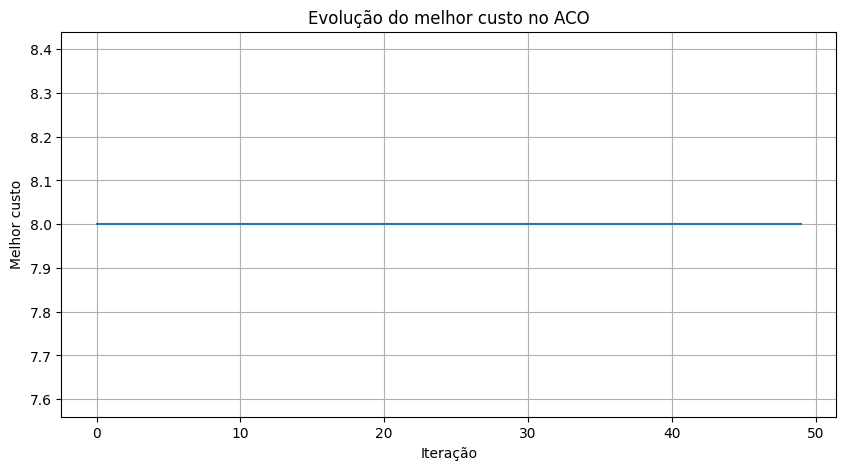


Matriz final de feromônio:
[[  0. 500.   0.   0.   0.   0.]
 [  0.   0. 500.   0.   0.   0.]
 [  0.   0.   0. 500.   0.   0.]
 [  0.   0.   0.   0. 500.   0.]
 [  0.   0.   0.   0.   0. 500.]
 [  0.   0.   0.   0.   0.   0.]]


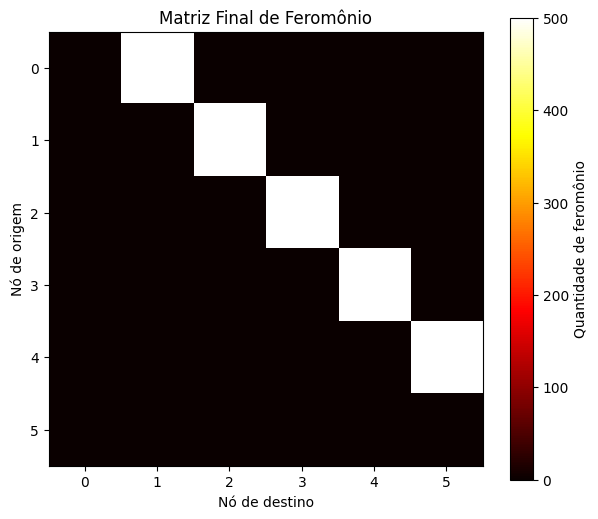

In [1]:
# ============================================================
# LABORATÓRIO 04 — ACO DO ZERO
# ============================================================

import numpy as np
import random
import matplotlib.pyplot as plt


# ============================================================
# 1. MATRIZ DE CUSTOS
# ============================================================

CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5


# ============================================================
# 2. PARÂMETROS DO ACO
# ============================================================

NUM_FORMIGAS = 20
NUM_ITERACOES = 50

ALPHA = 1.0
BETA = 2.0

TAXA_EVAPORACAO = 0.5
Q = 100


# ============================================================
# 3. SEMENTE PARA REPETIR O RESULTADO
# ============================================================

random.seed(42)
np.random.seed(42)


# ============================================================
# 4. MATRIZ DE FEROMÔNIO
# ============================================================

feromonio = np.ones_like(
    CUSTOS,
    dtype=float
)

# Onde não existe conexão,
# o feromônio deve ser zero.
feromonio[CUSTOS == np.inf] = 0

# Também não precisamos de feromônio
# do nó para ele mesmo.
np.fill_diagonal(
    feromonio,
    0
)


# ============================================================
# 5. DESCOBRIR VIZINHOS
# ============================================================

def obter_vizinhos(no):

    vizinhos = []

    for proximo in range(
        len(CUSTOS)
    ):

        # Verifica se existe conexão
        if (
            proximo != no
            and
            CUSTOS[no][proximo] != np.inf
        ):

            vizinhos.append(
                proximo
            )

    return vizinhos


# ============================================================
# 6. CALCULAR ATRATIVIDADE
# ============================================================

def calcular_atratividade(
    atual,
    proximo
):

    fer = feromonio[
        atual
    ][
        proximo
    ]

    custo = CUSTOS[
        atual
    ][
        proximo
    ]

    # Fórmula do ACO:
    # feromônio^ALPHA × (1/custo)^BETA

    atratividade = (
        (fer ** ALPHA)
        *
        ((1 / custo) ** BETA)
    )

    return atratividade


# ============================================================
# 7. CONSTRUIR A ROTA DE UMA FORMIGA
# ============================================================

def construir_rota():

    # Toda formiga começa na origem.
    rota = [ORIGEM]

    atual = ORIGEM

    # Continua até chegar ao destino.
    while atual != DESTINO:

        vizinhos = obter_vizinhos(
            atual
        )

        # Impede a formiga de voltar
        # para um nó já visitado.
        candidatos = [
            no
            for no in vizinhos
            if no not in rota
        ]

        # Se não houver saída possível,
        # a rota é descartada.
        if not candidatos:
            return None


        # ----------------------------------------
        # Calculando atratividade
        # ----------------------------------------

        atratividades = []

        for candidato in candidatos:

            valor = calcular_atratividade(
                atual,
                candidato
            )

            atratividades.append(
                valor
            )


        # ----------------------------------------
        # Transformando em probabilidades
        # ----------------------------------------

        soma = sum(
            atratividades
        )

        # Proteção caso todas as
        # atratividades sejam zero.
        if soma == 0:

            proximo = random.choice(
                candidatos
            )

        else:

            probabilidades = [
                valor / soma
                for valor in atratividades
            ]


            # ------------------------------------
            # Escolha probabilística
            # ------------------------------------

            proximo = random.choices(
                candidatos,
                weights=probabilidades,
                k=1
            )[0]


        # Adiciona o nó escolhido à rota.
        rota.append(
            proximo
        )

        atual = proximo


    return rota


# ============================================================
# 8. CALCULAR O CUSTO DE UMA ROTA
# ============================================================

def calcular_custo(
    rota
):

    custo_total = 0

    for i in range(
        len(rota) - 1
    ):

        origem = rota[i]
        destino = rota[i + 1]

        custo_total += CUSTOS[
            origem
        ][
            destino
        ]

    return custo_total


# ============================================================
# 9. EVAPORAÇÃO DO FEROMÔNIO
# ============================================================

def evaporar_feromonio():

    global feromonio

    feromonio *= (
        1 - TAXA_EVAPORACAO
    )

    # Continua deixando zero
    # onde não existe ligação.
    feromonio[
        CUSTOS == np.inf
    ] = 0

    np.fill_diagonal(
        feromonio,
        0
    )


# ============================================================
# 10. DEPÓSITO DE FEROMÔNIO
# ============================================================

def depositar_feromonio(
    rota,
    custo
):

    # Quanto menor o custo,
    # maior o depósito.
    deposito = Q / custo

    for i in range(
        len(rota) - 1
    ):

        origem = rota[i]
        destino = rota[i + 1]

        feromonio[
            origem
        ][
            destino
        ] += deposito


# ============================================================
# 11. EXECUTANDO A COLÔNIA
# ============================================================

melhor_rota = None

melhor_custo = float(
    "inf"
)

historico = []


for iteracao in range(
    NUM_ITERACOES
):

    rotas_encontradas = []


    # Cada formiga procura uma rota.
    for formiga in range(
        NUM_FORMIGAS
    ):

        rota = construir_rota()


        if rota is not None:

            custo = calcular_custo(
                rota
            )

            rotas_encontradas.append(
                (rota, custo)
            )


            # Verifica se é a melhor
            # solução até o momento.
            if custo < melhor_custo:

                melhor_custo = custo

                melhor_rota = (
                    rota.copy()
                )


    # Primeiro ocorre a evaporação.
    evaporar_feromonio()


    # Depois ocorre o reforço
    # dos caminhos encontrados.
    for rota, custo in rotas_encontradas:

        depositar_feromonio(
            rota,
            custo
        )


    # Guarda o melhor custo de
    # cada iteração para o gráfico.
    historico.append(
        melhor_custo
    )


# ============================================================
# 12. RESULTADO FINAL
# ============================================================

print(
    "\n========== RESULTADO =========="
)

print(
    "\nMelhor rota encontrada:"
)

print(
    melhor_rota
)

print(
    "\nMelhor custo:"
)

print(
    melhor_custo
)


# ============================================================
# 13. MOSTRANDO O CÁLCULO DA MELHOR ROTA
# ============================================================

print(
    "\nCálculo da melhor rota:"
)

for i in range(
    len(melhor_rota) - 1
):

    origem = melhor_rota[i]
    destino = melhor_rota[i + 1]

    print(
        f"{origem} -> {destino}"
        f" = {CUSTOS[origem][destino]}"
    )


# ============================================================
# 14. GRÁFICO DA EVOLUÇÃO
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    historico
)

plt.xlabel(
    "Iteração"
)

plt.ylabel(
    "Melhor custo"
)

plt.title(
    "Evolução do melhor custo no ACO"
)

plt.grid()

plt.show()


# ============================================================
# 15. MATRIZ FINAL DE FEROMÔNIO
# ============================================================

print(
    "\nMatriz final de feromônio:"
)

print(
    np.round(
        feromonio,
        2
    )
)


plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    feromonio,
    cmap="hot"
)

plt.colorbar(
    label="Quantidade de feromônio"
)

plt.xlabel(
    "Nó de destino"
)

plt.ylabel(
    "Nó de origem"
)

plt.title(
    "Matriz Final de Feromônio"
)

plt.xticks(
    range(len(CUSTOS))
)

plt.yticks(
    range(len(CUSTOS))
)

plt.show()